# Gatestrain vs STFT Narrowband Cleaning — Comparison

This notebook implements a simplified Python version of the **gatestrain** method
(Steltner, Papa & Eggenstein 2022, Phys. Rev. D 105, 022005) and compares it
with the STFT-based narrowband cleaning in `readligo.preprocessing`.

**gatestrain** operates on full-bandwidth whitened strain (4 kHz) using adaptive
dual-threshold time-domain gating. Our STFT cleaning operates on narrowband
post-heterodyne data (1 Hz) using a chi-squared test on STFT columns.
Both produce a binary clean/contaminated decision per time interval.

In [17]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, stats

import readligo
from readligo import loaddata, process_band, apply_dq_mask, clean_narrowband, heterodyne_downsample

## 1. Python gatestrain implementation

Following Section III of Steltner+ 2022:
1. High-pass at 10 Hz (8th-order Butterworth)
2. Reference PSD via median-averaged periodograms (~100 segments)
3. Whiten in frequency domain → $h_w(t)$ with $\sigma \approx 1$
4. Robust $\sigma$ via harmonic mean of per-chunk standard deviations
5. Dual-threshold gating: $H^{\mathrm{high}}$ seeds, $H^{\mathrm{low}}$ extent, cluster within $\tau_{\mathrm{dur}}$
6. Iterative: lower $H^{\mathrm{high}}$ until noise ratio $R \leq R^{\mathrm{th}}$

In [18]:
def estimate_reference_psd(
    strain: np.ndarray, dq_mask_fs: np.ndarray, fs: int = 4096, seg_dur: float = 32.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Median-averaged PSD from fully-DQ-good segments only."""
    nperseg = int(seg_dur * fs)
    n_segs = len(strain) // nperseg
    win = signal.windows.hann(nperseg)
    win_ss = float(np.sum(win ** 2))
    periodograms = []
    for i in range(n_segs):
        sl = slice(i * nperseg, (i + 1) * nperseg)
        if not np.all(dq_mask_fs[sl]):
            continue
        seg_fft = np.fft.rfft(strain[sl] * win)
        periodograms.append((2.0 / (fs * win_ss)) * np.abs(seg_fft) ** 2)
    freqs = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    if len(periodograms) < 2:
        return freqs, np.ones_like(freqs)
    return freqs, np.median(np.array(periodograms), axis=0) / np.log(2)


def whiten(
    strain: np.ndarray, fs: int, psd_freqs: np.ndarray, psd_values: np.ndarray,
    f_highpass: float = 10.0,
) -> np.ndarray:
    """Whiten strain in the frequency domain. Zeros frequencies below f_highpass."""
    n = len(strain)
    h_f = np.fft.rfft(strain)
    freqs_fft = np.fft.rfftfreq(n, d=1.0 / fs)
    psd_interp = np.interp(freqs_fft, psd_freqs, psd_values)
    filt = np.zeros_like(psd_interp)
    valid = (freqs_fft >= f_highpass) & (psd_interp > 0)
    filt[valid] = 1.0 / np.sqrt(psd_interp[valid])
    return np.fft.irfft(h_f * filt, n=n)


def robust_sigma(
    h_w: np.ndarray, dq_mask_fs: np.ndarray, fs: int, chunk_dur: float = 10.0,
) -> float:
    """Harmonic mean of per-chunk std, using only fully-DQ-good chunks."""
    chunk_samples = int(chunk_dur * fs)
    n_chunks = len(h_w) // chunk_samples
    sigmas = []
    for i in range(n_chunks):
        sl = slice(i * chunk_samples, (i + 1) * chunk_samples)
        if not np.all(dq_mask_fs[sl]):
            continue
        sigmas.append(np.std(h_w[sl]))
    if len(sigmas) == 0:
        return float(np.std(h_w))
    sigmas = np.array(sigmas)
    return float(len(sigmas) / np.sum(1.0 / np.maximum(sigmas, 1e-30)))


def find_gates(
    h_w: np.ndarray, dq_mask_fs: np.ndarray,
    fs: int, h_high: float, h_low: float, tau_dur: float = 0.5,
) -> list[tuple[int, int]]:
    """Dual-threshold gate finding, restricted to DQ-good samples."""
    abs_hw = np.abs(h_w)
    tau_samples = int(tau_dur * fs)
    # Only consider DQ-good samples for threshold exceedances
    high_idx = np.where((abs_hw > h_high) & dq_mask_fs)[0]
    low_idx = np.where((abs_hw > h_low) & dq_mask_fs)[0]
    if len(high_idx) == 0 or len(low_idx) == 0:
        return []
    gaps = np.diff(low_idx)
    split_points = np.where(gaps > tau_samples)[0] + 1
    groups = np.split(low_idx, split_points)
    surviving: list[tuple[int, int]] = []
    for group in groups:
        if len(group) == 0:
            continue
        g_start, g_end = int(group[0]), int(group[-1])
        has_seed = False
        for h_idx in high_idx:
            if g_start - tau_samples <= h_idx <= g_end + tau_samples:
                has_seed = True
                break
        if has_seed:
            surviving.append((g_start, g_end))
    return surviving


def apply_gates(
    strain: np.ndarray, gates: list[tuple[int, int]], fs: int, taper_dur: float = 0.25,
) -> np.ndarray:
    """Zero gate regions with half-cosine Tukey taper on each side."""
    gated = strain.copy()
    n = len(gated)
    taper_samples = int(taper_dur * fs)
    for g_start, g_end in gates:
        tap_in_start = max(0, g_start - taper_samples)
        tap_in_len = g_start - tap_in_start
        if tap_in_len > 0:
            t = np.linspace(0, 1, tap_in_len, endpoint=False)
            gated[tap_in_start:g_start] *= 0.5 * (1 + np.cos(np.pi * t))
        gated[g_start : g_end + 1] = 0.0
        tap_out_end = min(n, g_end + 1 + taper_samples)
        tap_out_len = tap_out_end - (g_end + 1)
        if tap_out_len > 0:
            t = np.linspace(0, 1, tap_out_len, endpoint=False)
            gated[g_end + 1 : tap_out_end] *= 0.5 * (1 - np.cos(np.pi * t))
    return gated


def noise_floor_ratio(
    gated_strain: np.ndarray, dq_mask_fs: np.ndarray,
    psd_ref_freqs: np.ndarray, psd_ref: np.ndarray,
    fs: int = 4096, f_low: float = 25.0, f_high: float = 40.0, seg_dur: float = 32.0,
) -> float:
    """R = mean(P_gated / P_ref) in [f_low, f_high] Hz (Eq. 1)."""
    freqs, psd_gated = estimate_reference_psd(gated_strain, dq_mask_fs, fs, seg_dur)
    mask = (freqs >= f_low) & (freqs <= f_high)
    psd_ref_interp = np.interp(freqs, psd_ref_freqs, psd_ref)
    ratio = psd_gated[mask] / np.maximum(psd_ref_interp[mask], 1e-60)
    return float(np.mean(ratio))


def gate_strain(
    strain: np.ndarray, channel_dict: dict[str, np.ndarray], fs: int = 4096, *,
    nl: float = 5.5, h_high_init: float = 50.0, h_high_min: float = 20.0,
    h_high_step: float = 10.0, tau_dur: float = 0.5, taper_dur: float = 0.25,
    r_target: float = 1.05, seg_dur: float = 32.0, f_highpass: float = 10.0,
    verbose: bool = True,
) -> tuple[np.ndarray, list[tuple[float, float]], np.ndarray]:
    """Python implementation of gatestrain (Steltner+ 2022).

    Returns (gated_strain, gate_intervals, h_w).
    gate_intervals is a list of (start_time_s, end_time_s) tuples.
    """
    # DQ mask
    dq_mask_1hz = (channel_dict["DATA"] == 1) & (channel_dict["CBC_CAT1"] == 1)
    dq_mask_fs = np.repeat(dq_mask_1hz, fs)

    # Replace NaN with 0
    strain_clean = np.copy(strain)
    strain_clean[np.isnan(strain_clean)] = 0.0

    # Step 1: high-pass filter
    sos = signal.butter(8, f_highpass, btype="high", fs=fs, output="sos")
    h_hp = signal.sosfiltfilt(sos, strain_clean)

    # Step 2: reference PSD (DQ-good segments only)
    psd_freqs, psd_ref = estimate_reference_psd(h_hp, dq_mask_fs, fs, seg_dur)

    # Step 3: whiten
    h_w = whiten(h_hp, fs, psd_freqs, psd_ref, f_highpass)

    # Step 4: robust sigma (DQ-good chunks only)
    sigma = robust_sigma(h_w, dq_mask_fs, fs, chunk_dur=10.0)
    h_low = nl * sigma
    if verbose:
        print(f"  sigma = {sigma:.2f},  H_low = {h_low:.1f}")

    # Steps 5-6: iterative gating
    h_high_sigma = h_high_init
    gated = h_hp.copy()
    all_gates: list[tuple[int, int]] = []

    iteration = 0
    while h_high_sigma >= h_high_min:
        iteration += 1
        h_high = h_high_sigma * sigma
        new_gates = find_gates(h_w, dq_mask_fs, fs, h_high, h_low, tau_dur)
        if not new_gates:
            if verbose:
                print(f"  iter {iteration}: H_high={h_high_sigma:.0f}\u03c3 \u2192 no new gates")
            h_high_sigma -= h_high_step
            continue
        all_gates.extend(new_gates)
        gated = apply_gates(h_hp, all_gates, fs, taper_dur)
        r = noise_floor_ratio(gated, dq_mask_fs, psd_freqs, psd_ref, fs)
        total_gated_s = sum((end - start + 1) / fs for start, end in all_gates)
        if verbose:
            print(
                f"  iter {iteration}: H_high={h_high_sigma:.0f}\u03c3, "
                f"{len(new_gates)} new gates, {len(all_gates)} total, "
                f"gated={total_gated_s:.2f}s, R={r:.4f}"
            )
        if r <= r_target:
            if verbose:
                print(f"  Converged (R={r:.4f} <= {r_target})")
            break
        h_high_sigma -= h_high_step

    gate_intervals = [(start / fs, (end + 1) / fs) for start, end in all_gates]
    return gated, gate_intervals, h_w


print("gatestrain functions defined.")

gatestrain functions defined.


## 2. Validate on a single O3a file

In [22]:
dirname = "/Users/saifa/Library/CloudStorage/OneDrive-weizmann.ac.il/O3a_marvin/"
hdf5_files = sorted(
    Path(dirname).glob("*.hdf5"),
    key=lambda p: int(p.stem.split("-")[-2]),
)
print(f"Found {len(hdf5_files)} O3a files")

# Load first file
strain, time, channel_dict = loaddata(str(hdf5_files[4]))
gps_start = time[0]
fs = 4096
print(f"GPS start: {gps_start}, duration: {len(strain)/fs:.0f} s")

Found 56 O3a files
GPS start: 1238179840.0, duration: 4096 s


In [23]:
# Run gatestrain
print("Running gatestrain...")
gated_strain, gate_intervals, h_w = gate_strain(strain, channel_dict, fs)

print(f"\nResults:")
print(f"  Gates found: {len(gate_intervals)}")
total_gated = sum(end - start for start, end in gate_intervals)
print(f"  Total gated: {total_gated:.3f} s ({100*total_gated/4096:.3f}%)")

Running gatestrain...
  sigma = 45.64,  H_low = 251.0
  iter 1: H_high=50σ, 7 new gates, 7 total, gated=64.79s, R=0.9438
  Converged (R=0.9438 <= 1.05)

Results:
  Gates found: 7
  Total gated: 64.786 s (1.582%)


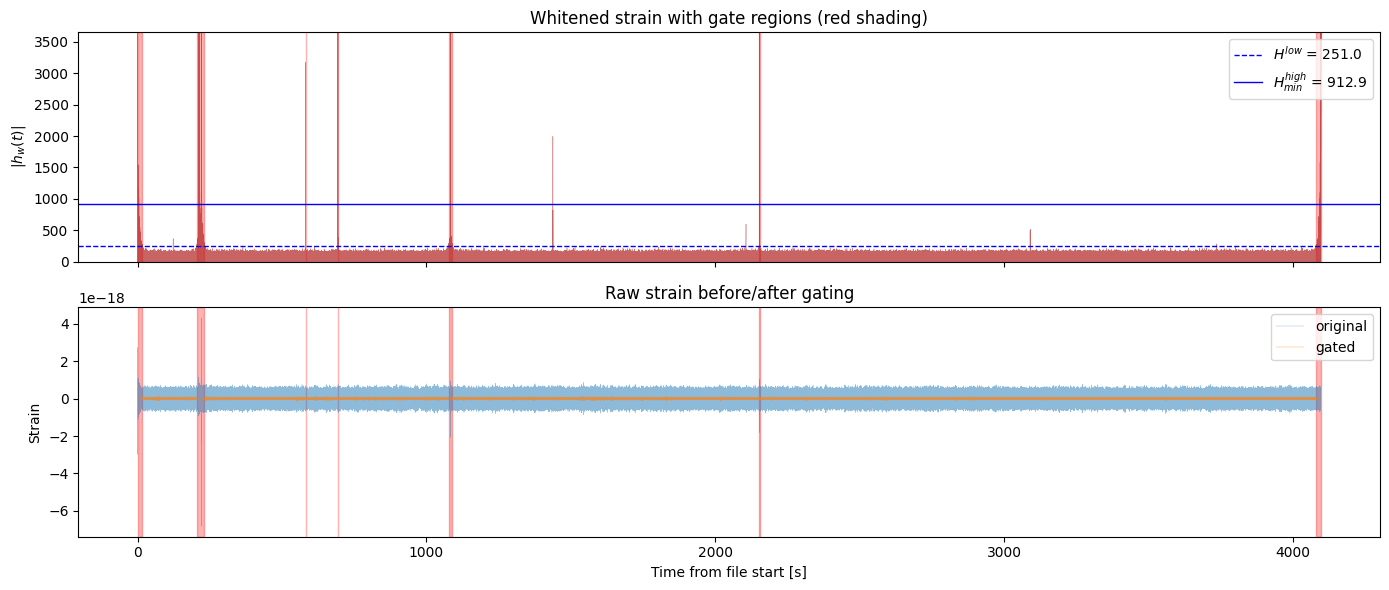

In [24]:
# Plot whitened strain with thresholds and gate regions
dq_mask_1hz = (channel_dict["DATA"] == 1) & (channel_dict["CBC_CAT1"] == 1)
dq_mask_fs_plot = np.repeat(dq_mask_1hz, fs)
sigma = robust_sigma(h_w, dq_mask_fs_plot, fs)
t_sec = np.arange(len(h_w)) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: |h_w(t)| with thresholds
axes[0].plot(t_sec, np.abs(h_w), lw=0.3, color="firebrick", alpha=0.7)
axes[0].axhline(5.5 * sigma, color="blue", ls="--", lw=1, label=f"$H^{{low}}$ = {5.5*sigma:.1f}")
axes[0].axhline(20 * sigma, color="blue", ls="-", lw=1, label=f"$H^{{high}}_{{min}}$ = {20*sigma:.1f}")
for g_start, g_end in gate_intervals:
    axes[0].axvspan(g_start, g_end, color="red", alpha=0.3)
axes[0].set_ylabel(r"$|h_w(t)|$")
axes[0].set_title("Whitened strain with gate regions (red shading)")
axes[0].legend(loc="upper right")
axes[0].set_ylim(0, min(80 * sigma, np.max(np.abs(h_w)) * 1.1))

# Bottom: raw strain before/after gating
axes[1].plot(t_sec, strain, lw=0.3, alpha=0.5, label="original")
axes[1].plot(t_sec, gated_strain, lw=0.3, alpha=0.7, label="gated")
for g_start, g_end in gate_intervals:
    axes[1].axvspan(g_start, g_end, color="red", alpha=0.3)
axes[1].set_ylabel("Strain")
axes[1].set_xlabel("Time from file start [s]")
axes[1].set_title("Raw strain before/after gating")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. Comparison A — Side-by-side timeline

Run both methods on the same file and visualise which time intervals each flags.

In [25]:
# Run STFT narrowband cleaning on the same file
f_band = (100, 101)
clean_strain_dq, dq_mask_1hz = apply_dq_mask(strain, channel_dict, fs)
narrowband, fs_new = heterodyne_downsample(clean_strain_dq, fs, f_band)
cleaned, sample_mask, diag = clean_narrowband(narrowband, dq_mask_1hz, fs_new)

print(f"STFT cleaning (band {f_band} Hz):")
print(f"  DQ-good STFT columns: {np.sum(diag['good_cols'])} / {len(diag['good_cols'])}")
artifact_cols = (diag["col_hits"] > 10) & diag["good_cols"]
print(f"  Artifact columns: {np.sum(artifact_cols)}")
print(f"  sample_mask bad: {np.sum(~sample_mask)} / {len(sample_mask)}")
print(f"  Duty factor (after cleaning): {np.mean(sample_mask):.3f}")

STFT cleaning (band (100, 101) Hz):
  DQ-good STFT columns: 129 / 129
  Artifact columns: 9
  sample_mask bad: 448 / 4096
  Duty factor (after cleaning): 0.891


In [26]:
# Build 1 Hz boolean masks for both methods
n_seconds = int(len(strain) / fs)  # 4096

# Gatestrain → 1 Hz mask (True = good)
gate_mask_1hz = np.ones(n_seconds, dtype=bool)
for g_start, g_end in gate_intervals:
    i_start = max(0, int(np.floor(g_start)))
    i_end = min(n_seconds, int(np.ceil(g_end)))
    gate_mask_1hz[i_start:i_end] = False

# STFT cleaning → already have sample_mask at fs_new Hz
# Also build a 1 Hz version from the STFT bad_col_mask
stft_mask_1hz = np.ones(n_seconds, dtype=bool)
time_bins = diag["time_bins"]
bad_col_mask = diag["bad_col_mask"]
nperseg_stft = len(diag["freq"])
win_dur = nperseg_stft / fs_new
for i, is_bad in enumerate(bad_col_mask):
    if is_bad:
        tc = time_bins[i]
        i_start = max(0, int(np.floor(tc - win_dur / 2)))
        i_end = min(n_seconds, int(np.ceil(tc + win_dur / 2)))
        stft_mask_1hz[i_start:i_end] = False

# DQ mask at 1 Hz
gps_axis = gps_start + np.arange(n_seconds)

print(f"Gatestrain: {np.sum(~gate_mask_1hz)} s flagged")
print(f"STFT clean: {np.sum(~stft_mask_1hz)} s flagged")
print(f"DQ flags:   {np.sum(~dq_mask_1hz)} s flagged")

Gatestrain: 71 s flagged
STFT clean: 448 s flagged
DQ flags:   0 s flagged


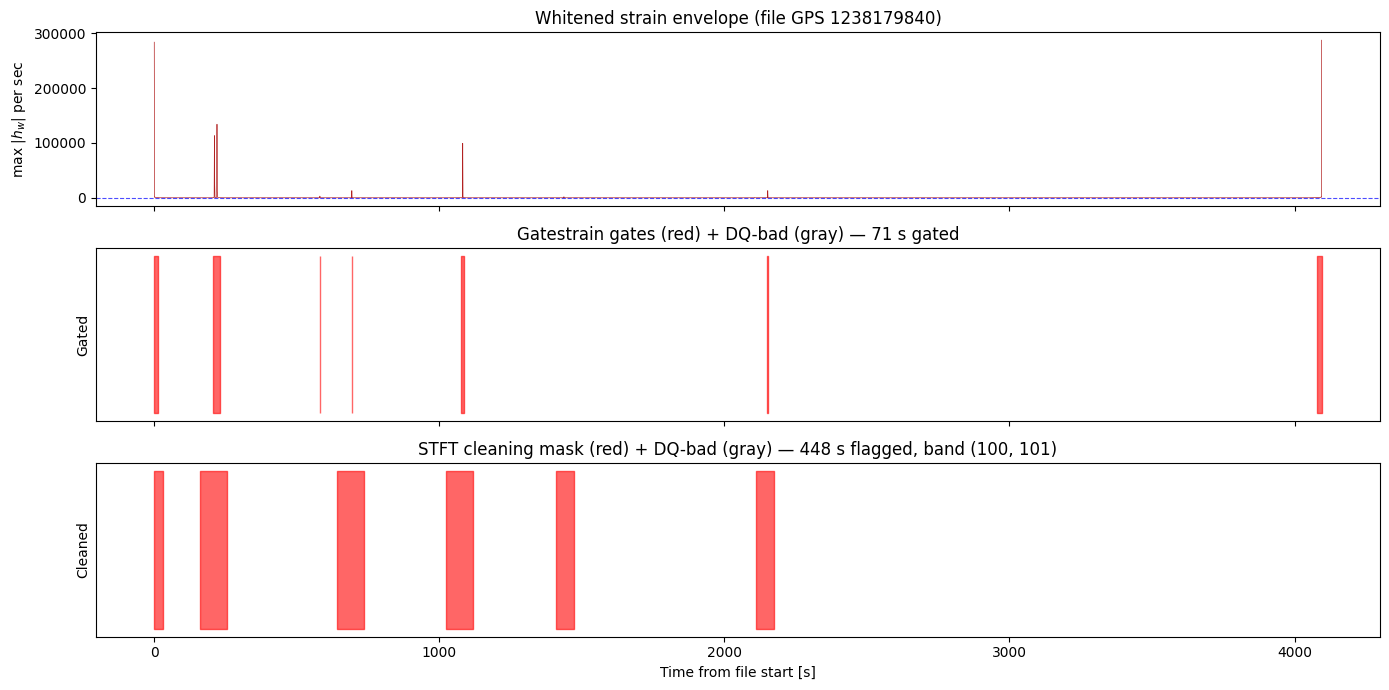

In [27]:
# Side-by-side timeline: 3 panels
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
t_sec = np.arange(n_seconds)

# Panel 1: |h_w(t)| (whitened strain envelope at lower resolution for visibility)
hw_1hz = np.array([
    np.max(np.abs(h_w[i * fs : (i + 1) * fs])) for i in range(n_seconds)
])
axes[0].plot(t_sec, hw_1hz, lw=0.5, color="firebrick")
axes[0].axhline(5.5 * sigma, color="blue", ls="--", lw=0.8, alpha=0.7)
axes[0].set_ylabel(r"max $|h_w|$ per sec")
axes[0].set_title(f"Whitened strain envelope (file GPS {gps_start:.0f})")

# Panel 2: gatestrain gate mask
axes[1].fill_between(t_sec, 0, 1, where=~gate_mask_1hz, color="red", alpha=0.6)
axes[1].fill_between(t_sec, 0, 1, where=~dq_mask_1hz, color="gray", alpha=0.3)
axes[1].set_ylabel("Gated")
axes[1].set_yticks([])
axes[1].set_title(f"Gatestrain gates (red) + DQ-bad (gray) — {np.sum(~gate_mask_1hz)} s gated")

# Panel 3: STFT cleaning mask
axes[2].fill_between(t_sec, 0, 1, where=~stft_mask_1hz, color="red", alpha=0.6)
axes[2].fill_between(t_sec, 0, 1, where=~dq_mask_1hz, color="gray", alpha=0.3)
axes[2].set_ylabel("Cleaned")
axes[2].set_yticks([])
axes[2].set_xlabel("Time from file start [s]")
axes[2].set_title(f"STFT cleaning mask (red) + DQ-bad (gray) — {np.sum(~stft_mask_1hz)} s flagged, band {f_band}")

plt.tight_layout()
plt.show()

## 4. Comparison B — Duty factor / data loss across files

Loop over all O3a files and compare how much data each method removes.
Compare totals with Table II from Steltner+ 2022.

In [28]:
results = []

for i, filepath in enumerate(hdf5_files):
    print(f"[{i+1}/{len(hdf5_files)}] {filepath.name} ... ", end="", flush=True)

    s, t, ch = loaddata(str(filepath))
    gps = t[0]
    n_sec = len(s) // fs

    # DQ mask
    dq = (ch["DATA"] == 1) & (ch["CBC_CAT1"] == 1)
    dq_bad_s = int(np.sum(~dq))

    # Gatestrain
    _, gates, _ = gate_strain(s, ch, fs, verbose=False)
    gate_total_s = sum(end - start for start, end in gates)

    # STFT cleaning
    cs, dq1 = apply_dq_mask(s, ch, fs)
    nb, fsn = heterodyne_downsample(cs, fs, f_band)
    _, sm, dg = clean_narrowband(nb, dq1, fsn)
    stft_bad_s = int(np.sum(~sm))  # at fs_new Hz, so 1 sample = 1 second

    # Artifact columns only (DQ-good but chi-sq flagged)
    if dg:
        art = int(np.sum((dg["col_hits"] > 10) & dg["good_cols"]))
    else:
        art = 0

    results.append({
        "gps_start": gps,
        "dq_bad_s": dq_bad_s,
        "gate_n": len(gates),
        "gate_s": gate_total_s,
        "stft_bad_s": stft_bad_s,
        "stft_artifacts": art,
    })
    print(f"gates={len(gates)} ({gate_total_s:.1f}s), stft_bad={stft_bad_s}s, artifacts={art}")

print("\nDone.")

[1/56] H-H1_GWOSC_O3a_4KHZ_R1-1238163456-4096.hdf5 ... gates=4 (14.0s), stft_bad=2688s, artifacts=1
[2/56] H-H1_GWOSC_O3a_4KHZ_R1-1238167552-4096.hdf5 ... gates=5 (16.1s), stft_bad=544s, artifacts=1
[3/56] H-H1_GWOSC_O3a_4KHZ_R1-1238171648-4096.hdf5 ... gates=9 (20.3s), stft_bad=448s, artifacts=7
[4/56] H-H1_GWOSC_O3a_4KHZ_R1-1238175744-4096.hdf5 ... gates=8 (22.9s), stft_bad=416s, artifacts=8
[5/56] H-H1_GWOSC_O3a_4KHZ_R1-1238179840-4096.hdf5 ... gates=7 (64.8s), stft_bad=448s, artifacts=9
[6/56] H-H1_GWOSC_O3a_4KHZ_R1-1238183936-4096.hdf5 ... gates=3 (6.4s), stft_bad=96s, artifacts=2
[7/56] H-H1_GWOSC_O3a_4KHZ_R1-1238188032-4096.hdf5 ... gates=7 (15.7s), stft_bad=352s, artifacts=7
[8/56] H-H1_GWOSC_O3a_4KHZ_R1-1238192128-4096.hdf5 ... gates=8 (7.7s), stft_bad=352s, artifacts=7
[9/56] H-H1_GWOSC_O3a_4KHZ_R1-1238196224-4096.hdf5 ... gates=4 (15.5s), stft_bad=1408s, artifacts=1
[10/56] H-H1_GWOSC_O3a_4KHZ_R1-1238200320-4096.hdf5 ... gates=6 (27.6s), stft_bad=320s, artifacts=6
[11/56] H-

In [29]:
# Summary table
total_files = len(results)
total_duration_s = total_files * 4096
total_dq_bad = sum(r["dq_bad_s"] for r in results)
total_gate_n = sum(r["gate_n"] for r in results)
total_gate_s = sum(r["gate_s"] for r in results)
total_stft_bad = sum(r["stft_bad_s"] for r in results)
total_stft_art = sum(r["stft_artifacts"] for r in results)
files_with_gates = sum(1 for r in results if r["gate_n"] > 0)
files_with_stft_art = sum(1 for r in results if r["stft_artifacts"] > 0)

print("=" * 70)
print(f"{'Metric':<35} {'Gatestrain':>15} {'STFT clean':>15}")
print("=" * 70)
print(f"{'Files processed':<35} {total_files:>15}")
print(f"{'Total data':<35} {total_duration_s/3600:>15.1f} h")
print(f"{'DQ-bad (total)':<35} {total_dq_bad/3600:>15.1f} h")
print(f"{'Files with events':<35} {files_with_gates:>15} {files_with_stft_art:>15}")
print(f"{'Total events':<35} {total_gate_n:>15} {total_stft_art:>15}")
print(f"{'Data removed [s]':<35} {total_gate_s:>15.1f} {total_stft_bad:>15.0f}")
print(f"{'Data removed [h]':<35} {total_gate_s/3600:>15.3f} {total_stft_bad/3600:>15.3f}")
print(f"{'Fraction removed':<35} {total_gate_s/total_duration_s:>15.5f} {total_stft_bad/total_duration_s:>15.5f}")
print("=" * 70)
print(f"\nFor reference, Table II (Steltner+ 2022) reports for O3a-H1:")
print(f"  gatestrain: 11581 gates, 38236.8 s = 10.6 h zeroed out")
print(f"  self-gating: 20205 gates, 141070.9 s = 39.2 h zeroed out")
print(f"  (over ~5977 half-hour SFTs = ~2988.5 h total data)")

Metric                                   Gatestrain      STFT clean
Files processed                                  56
Total data                                     63.7 h
DQ-bad (total)                                 11.5 h
Files with events                                56              53
Total events                                    294             264
Data removed [s]                              900.6           56064
Data removed [h]                              0.250          15.573
Fraction removed                            0.00393         0.24442

For reference, Table II (Steltner+ 2022) reports for O3a-H1:
  gatestrain: 11581 gates, 38236.8 s = 10.6 h zeroed out
  self-gating: 20205 gates, 141070.9 s = 39.2 h zeroed out
  (over ~5977 half-hour SFTs = ~2988.5 h total data)


## 5. Comparison C — Gate overlap (confusion matrix)

Map both methods to 1 Hz boolean masks and compute overlap statistics.
- **Both flag**: glitches caught by both methods
- **Gatestrain only**: broadband glitches outside the STFT band
- **STFT only**: subtle narrowband artifacts missed by broadband whitening

In [30]:
# Aggregate confusion matrix across all files
# Only count DQ-good seconds (both methods agree DQ-bad is bad)
cm = {"both_bad": 0, "gate_only": 0, "stft_only": 0, "both_good": 0, "dq_bad": 0}

for i, filepath in enumerate(hdf5_files):
    print(f"[{i+1}/{len(hdf5_files)}] {filepath.name} ... ", end="", flush=True)

    s, t, ch = loaddata(str(filepath))
    gps = t[0]
    n_sec = len(s) // fs

    dq = (ch["DATA"] == 1) & (ch["CBC_CAT1"] == 1)

    # Gatestrain
    _, gates, _ = gate_strain(s, ch, fs, verbose=False)
    g_mask = np.ones(n_sec, dtype=bool)
    for g_start, g_end in gates:
        g_mask[max(0, int(np.floor(g_start))):min(n_sec, int(np.ceil(g_end)))] = False

    # STFT cleaning
    cs, dq1 = apply_dq_mask(s, ch, fs)
    nb, fsn = heterodyne_downsample(cs, fs, f_band)
    _, sm, dg = clean_narrowband(nb, dq1, fsn)

    s_mask = np.ones(n_sec, dtype=bool)
    if dg:
        for j, is_bad in enumerate(dg["bad_col_mask"]):
            if is_bad:
                tc = dg["time_bins"][j]
                wd = len(dg["freq"]) / fsn
                lo = max(0, int(np.floor(tc - wd / 2)))
                hi = min(n_sec, int(np.ceil(tc + wd / 2)))
                s_mask[lo:hi] = False

    # Count in DQ-good seconds only
    dq_good = dq[:n_sec]
    cm["dq_bad"] += int(np.sum(~dq_good))
    dq_g = dq_good

    gate_bad = ~g_mask & dq_g
    stft_bad = ~s_mask & dq_g

    cm["both_bad"] += int(np.sum(gate_bad & stft_bad))
    cm["gate_only"] += int(np.sum(gate_bad & ~stft_bad))
    cm["stft_only"] += int(np.sum(~gate_bad & stft_bad))
    cm["both_good"] += int(np.sum(~gate_bad & ~stft_bad & dq_g))
    print("done")

print("\nConfusion matrix (DQ-good seconds only):")
print(f"  Both flag as bad:    {cm['both_bad']:>8} s")
print(f"  Gatestrain only:     {cm['gate_only']:>8} s")
print(f"  STFT only:           {cm['stft_only']:>8} s")
print(f"  Both flag as good:   {cm['both_good']:>8} s")
print(f"  DQ-bad (excluded):   {cm['dq_bad']:>8} s")

[1/56] H-H1_GWOSC_O3a_4KHZ_R1-1238163456-4096.hdf5 ... done
[2/56] H-H1_GWOSC_O3a_4KHZ_R1-1238167552-4096.hdf5 ... done
[3/56] H-H1_GWOSC_O3a_4KHZ_R1-1238171648-4096.hdf5 ... 

KeyboardInterrupt: 

In [ ]:
# Visualise confusion matrix
labels = ["Both bad", "Gatestrain\nonly", "STFT only", "Both good"]
values = [cm["both_bad"], cm["gate_only"], cm["stft_only"], cm["both_good"]]
colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val} s", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Seconds (DQ-good only)")
ax.set_title(f"Gate overlap: gatestrain vs STFT cleaning ({f_band} Hz)")
plt.tight_layout()
plt.show()

## 6. Comparison D — Are the methods complementary?

Run gatestrain first, then feed the gated strain into `process_band()`.
Compare the number of STFT artifact columns with vs without pre-gating.

- If pre-gating **reduces** artifact columns → the methods are complementary
- If the STFT cleaner finds the **same** artifacts → gatestrain is redundant for narrowband CW work

In [ ]:
comp_results = []

for i, filepath in enumerate(hdf5_files):
    print(f"[{i+1}/{len(hdf5_files)}] {filepath.name} ... ", end="", flush=True)

    s, t, ch = loaddata(str(filepath))
    gps = t[0]

    # Without pre-gating: standard pipeline
    cs1, dq1 = apply_dq_mask(s, ch, fs)
    nb1, fsn1 = heterodyne_downsample(cs1, fs, f_band)
    _, sm1, dg1 = clean_narrowband(nb1, dq1, fsn1)
    art1 = int(np.sum((dg1["col_hits"] > 10) & dg1["good_cols"])) if dg1 else 0
    bad1 = int(np.sum(~sm1))

    # With pre-gating: gatestrain first, then pipeline
    gated_s, _, _ = gate_strain(s, ch, fs, verbose=False)
    cs2, dq2 = apply_dq_mask(gated_s, ch, fs)
    nb2, fsn2 = heterodyne_downsample(cs2, fs, f_band)
    _, sm2, dg2 = clean_narrowband(nb2, dq2, fsn2)
    art2 = int(np.sum((dg2["col_hits"] > 10) & dg2["good_cols"])) if dg2 else 0
    bad2 = int(np.sum(~sm2))

    comp_results.append({
        "gps_start": gps,
        "art_no_gate": art1,
        "art_with_gate": art2,
        "bad_no_gate": bad1,
        "bad_with_gate": bad2,
    })
    print(f"artifacts: {art1} → {art2}, bad_samples: {bad1} → {bad2}")

print("\nDone.")

In [ ]:
# Summary
total_art_no = sum(r["art_no_gate"] for r in comp_results)
total_art_with = sum(r["art_with_gate"] for r in comp_results)
total_bad_no = sum(r["bad_no_gate"] for r in comp_results)
total_bad_with = sum(r["bad_with_gate"] for r in comp_results)

print("=" * 60)
print(f"{'Metric':<35} {'No pre-gate':>12} {'With pre-gate':>12}")
print("=" * 60)
print(f"{'Total artifact columns':<35} {total_art_no:>12} {total_art_with:>12}")
print(f"{'Total bad samples':<35} {total_bad_no:>12} {total_bad_with:>12}")
print("=" * 60)

if total_art_no > 0:
    reduction = (total_art_no - total_art_with) / total_art_no * 100
    print(f"\nPre-gating reduced STFT artifacts by {reduction:.1f}%")
    if reduction > 10:
        print("→ The methods are complementary: gatestrain catches glitches that the STFT misses.")
    else:
        print("→ The STFT cleaner catches the same artifacts regardless of pre-gating.")